# **🌳 '최저 시급' 데이터셋을 직접 수집해봅시다**

🌱 '최저임금위원회' 사이트 - [최저임금제도] - [최저임금 현황] - [연도별 최저임금 결정현황]

각 단계에 맞추어 '**미래의 최저 시급을 예측하는 모델**'을 제작해보세요.

✔️ **[파일] - [Drive에 사본 저장]**

# **[단계1] 데이터 수집 및 불러오기**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
files.upload()

Saving minimum wage law.csv to minimum wage law.csv


{'minimum wage law.csv': b'\xef\xbb\xbf\xec\x97\xb0\xeb\x8f\x84,\xec\xb5\x9c\xec\xa0\x80\xec\x8b\x9c\xea\xb8\x89\r\n2001,1865\r\n2002,2100\r\n2003,2275\r\n2004,2510\r\n2005,2840\r\n2006,3100\r\n2007,3480\r\n2008,3770\r\n2009,4000\r\n2010,4110\r\n2011,4320\r\n2012,4580\r\n2013,4860\r\n2014,5210\r\n2015,5580\r\n2016,6030\r\n2017,6470\r\n2018,7530\r\n2019,8350\r\n2020,8590\r\n2021,8720\r\n2022,9160\r\n2023,9620\r\n2024,9860\r\n2025,10030\r\n2026,10320\r\n'}

In [ ]:
df = pd.read_csv('minimum wage law.csv')
df.head()

,연도,최저시급
0,2001,1865
1,2002,2100
2,2003,2275
3,2004,2510
4,2005,2840


# **[단계2] 데이터 전처리**

In [ ]:
# ① 결측치 확인
df.isnull().sum()

,0
연도,0
최저시급,0


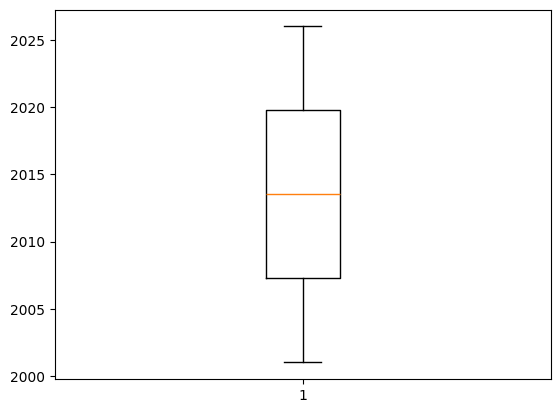

In [ ]:
# ② 이상치 확인
plt.boxplot(df['연도'])
plt.show()

# **[단계3] 독립변수와 종속변수 설정하기**

In [ ]:
x = df[['연도']]
y = df['최저시급']

# **[단계4] 데이터 쪼개기**

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

# **[단계5] 단순 선형회귀 모델 제작**

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
model.coef_, model.intercept_

(array([362.3013518]), np.float64(-723727.7122485987))

# **[단계6] 모델 성능 평가**

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

Predicted = model.predict(x_test) #모델 예측
MSE = mean_squared_error(y_test, Predicted)
RMSE = np.sqrt(MSE) #sqrt() = 제곱근

print(f"MSE(평균제곱오차): {MSE:.2f}")
print(f"RMSE(평균제곱근오차): {RMSE:.2f}")

MSE(평균제곱오차): 186608.33
RMSE(평균제곱근오차): 431.98


In [ ]:
from sklearn.metrics import r2_score
Predicted = model.predict(x_test)
r2_score_model = r2_score(y_test, Predicted)

print(f"r2_score(결정계수): {r2_score_model:.2f}")

r2_score(결정계수): 0.96


# **[단계7] 최저시급 예측 모델 구현하기**

In [ ]:
print("최저 시급이 궁금한 연도를 입력해주세요.") #예측을 위한 데이터 입력
year = int(input("year : "))

salary_predict = model.predict([[year]]) # ★ 입력받은 데이터로 예측

print("예상 최저 시급은 %d원 입니다." %salary_predict[0])

최저 시급이 궁금한 연도를 입력해주세요.
year : 2028
예상 최저 시급은 11019원 입니다.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
